In [91]:
import numpy as np

In [92]:
class LinearRegressor:
    def __init__(self, max_iterations=1000, learning_rate=0.01, alpha = 0.5, regularization = None):
        self.max_iterations = max_iterations
        self.learning_rate = learning_rate
        self.regularization = regularization
        self.alpha = alpha
        self.w = None           
        self.b = None

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.n_samples, self.n_features = X.shape

        self.w = np.random.randn(self.n_features)
        self.b = np.random.randn()

        if self.regularization == 'L1':
            self.regularization_f = lambda w, alpha: alpha * np.sign(w)
        elif self.regularization == 'L2':
            self.regularization_f = lambda w, alpha: alpha * w
        else:
            self.regularization_f = lambda w, alpha: 0


        for _ in range(self.max_iterations):
            y_pred = X.dot(self.w) + self.b
            error = y_pred - y

            dw = (2 / self.n_samples) * X.T.dot(error) + self.regularization_f(self.w, self.alpha)
            db = 2/self.n_samples * np.sum(error) 

            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict(self, X):
        X = np.array(X)
        return X.dot(self.w) + self.b
        

In [93]:
import matplotlib.pyplot as plt

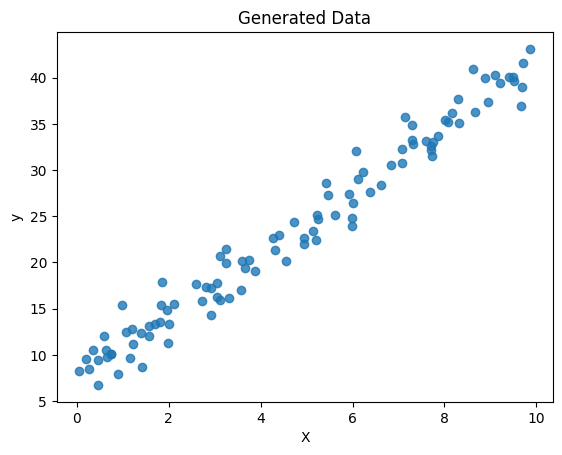

In [94]:
np.random.seed(42)
X = np.random.rand(100, 1) * 10  

true_w = 3.5
true_b = 7.0

y = true_w * X[:, 0] + true_b + np.random.randn(100) * 2  

plt.scatter(X, y, alpha=0.8)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Generated Data')
plt.show()

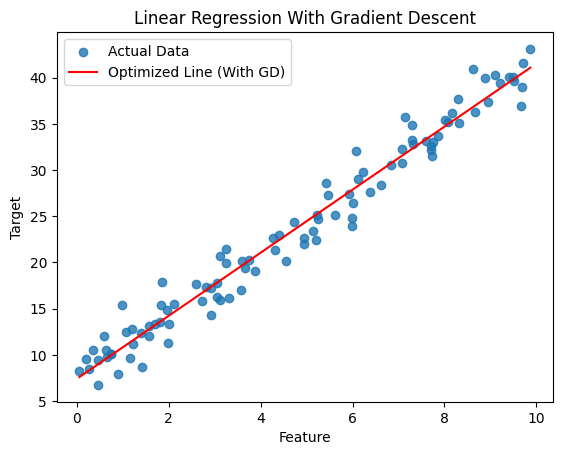

In [95]:
lr = LinearRegressor()
lr.fit(X, y)

X_line = np.linspace(min(X), max(X), 100).reshape(-1, 1)
y_line = lr.predict(X_line)

plt.scatter(X, y, label='Actual Data', alpha=0.8)
plt.plot(X_line, y_line, color='red', label='Optimized Line (With GD)')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Linear Regression With Gradient Descent')
plt.legend()
plt.show()

Линейная регрессия без регуляризации:
MAE: 0.3707, R²: 0.9946
[ 3.4672708  -2.03662279  4.75858035]
Линейная регрессия с L1-регуляризацией:
MAE: 0.3979, R²: 0.9940
[ 3.39678454 -1.99276828  4.70669578]
Линейная регрессия с L2-регуляризацией:
MAE: 0.5153, R²: 0.9905
[ 3.2379328  -1.96073322  4.51531866]


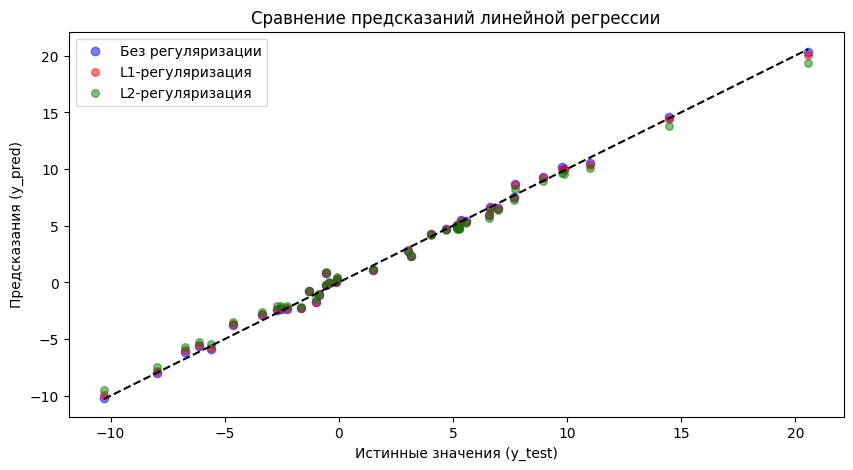

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(42)
n_samples = 200
n_features = 3

X = np.random.randn(n_samples, n_features)
true_w = np.array([3.5, -2.1, 4.7])
true_b = 1.2
y = X.dot(true_w) + true_b + np.random.randn(n_samples) * 0.5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_no_reg = LinearRegressor(max_iterations=1000, learning_rate=0.01, regularization=None)
model_no_reg.fit(X_train, y_train)

model_l1 = LinearRegressor(max_iterations=1000, learning_rate=0.01, alpha=0.1, regularization='L1')
model_l1.fit(X_train, y_train)

model_l2 = LinearRegressor(max_iterations=1000, learning_rate=0.01, alpha=0.1, regularization='L2')
model_l2.fit(X_train, y_train)

y_pred_no_reg = model_no_reg.predict(X_test)
y_pred_l1 = model_l1.predict(X_test)
y_pred_l2 = model_l2.predict(X_test)

mae_no_reg = mean_absolute_error(y_test, y_pred_no_reg)
r2_no_reg = r2_score(y_test, y_pred_no_reg)

mae_l1 = mean_absolute_error(y_test, y_pred_l1)
r2_l1 = r2_score(y_test, y_pred_l1)

mae_l2 = mean_absolute_error(y_test, y_pred_l2)
r2_l2 = r2_score(y_test, y_pred_l2)


print('Линейная регрессия без регуляризации:')
print(f'MAE: {mae_no_reg:.4f}, R²: {r2_no_reg:.4f}')
print(model_no_reg.w)
print('Линейная регрессия с L1-регуляризацией:')
print(f'MAE: {mae_l1:.4f}, R²: {r2_l1:.4f}')
print(model_l1.w)
print('Линейная регрессия с L2-регуляризацией:')
print(f'MAE: {mae_l2:.4f}, R²: {r2_l2:.4f}')
print(model_l2.w)


plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_no_reg, color='blue', alpha=0.5, label='Без регуляризации')
plt.scatter(y_test, y_pred_l1, color='red', alpha=0.5, s=30, label='L1-регуляризация')
plt.scatter(y_test, y_pred_l2, color='green', alpha=0.5, s=30, label='L2-регуляризация')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black', linestyle='--')
plt.xlabel('Истинные значения (y_test)')
plt.ylabel('Предсказания (y_pred)')
plt.title('Сравнение предсказаний линейной регрессии')
plt.legend()
plt.show()